<a href="https://colab.research.google.com/github/Abhinavapsomayaji-AI/AI-Assisted-Automatic-Traffic-Signaling-System-AIATSS-/blob/main/AIATSS_Traffic_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AI ASSISTED AUTOMATIC TRAFFIC SIGNALING SYSTEM(AIATSS)



**IF YOU WANT TO SKIP ALL THE STEPS OF MAKING THE ALGORITHEM WORK JUST GO TO THE FINAL CELL AND THE SECOND FINAL CELL AND PLAY**

Creating an initial layout(the road, lanes, addng vehicles,etc)


pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


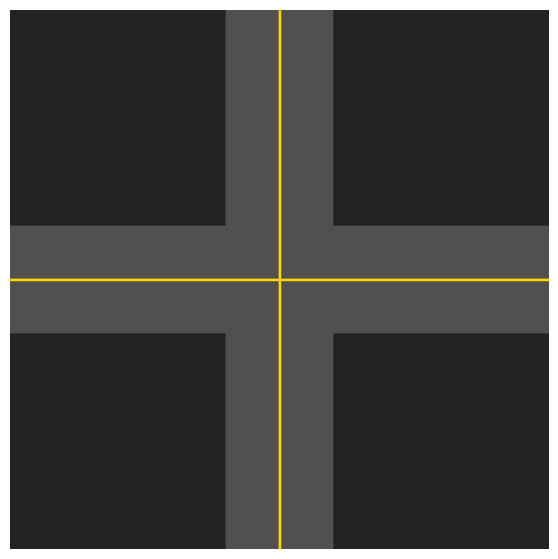

In [ ]:
# 1. Install prerequisites and switch Pygame into virtual engine mode
!pip install pygame matplotlib opencv-python
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

import pygame
import matplotlib.pyplot as plt

# 2. Dimensions & Core Settings
SCREEN_WIDTH = 600
SCREEN_HEIGHT = 600
ROAD_WIDTH = 120

pygame.init()
screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))

# 3. Design Color Specs (RGB)
DARK_CITY = (35, 35, 35)      # Dark city background grid
ROAD_GRAY = (80, 80, 80)      # High-quality asphalt
MARKER_YELLOW = (255, 215, 0) # Clear yellow line divides

# 4. Drawing Operations
screen.fill(DARK_CITY)

# Render vertical corridor road
pygame.draw.rect(screen, ROAD_GRAY, ((SCREEN_WIDTH // 2) - (ROAD_WIDTH // 2), 0, ROAD_WIDTH, SCREEN_HEIGHT))

# Render horizontal corridor road
pygame.draw.rect(screen, ROAD_GRAY, (0, (SCREEN_HEIGHT // 2) - (ROAD_WIDTH // 2), SCREEN_WIDTH, ROAD_WIDTH))

# Draw the yellow center road dividers (Horizontal & Vertical)
pygame.draw.line(screen, MARKER_YELLOW, (SCREEN_WIDTH // 2, 0), (SCREEN_WIDTH // 2, SCREEN_HEIGHT), 3)
pygame.draw.line(screen, MARKER_YELLOW, (0, SCREEN_HEIGHT // 2), (SCREEN_WIDTH, SCREEN_HEIGHT // 2), 3)

# 5. Extract Matrix and Force Display inside Google Colab
pixel_matrix = pygame.surfarray.array3d(screen)
pixel_matrix = pixel_matrix.transpose([1, 0, 2]) # Align display dimensions correctly

# Use matplotlib to plot the image array directly onto the screen
plt.figure(figsize=(7, 7))
plt.imshow(pixel_matrix)
plt.axis("off")  # Clear background chart rulers and numbers
plt.show()



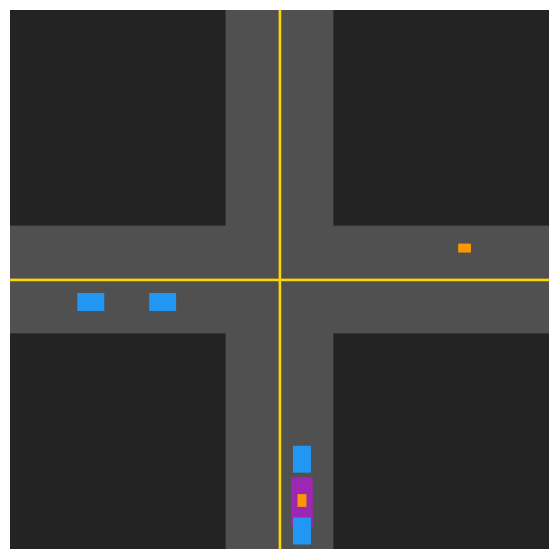

In [ ]:
import pygame
import random
import matplotlib.pyplot as plt

SCREEN_WIDTH = 600
SCREEN_HEIGHT = 600
ROAD_WIDTH = 120

pygame.init()
screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))

DARK_CITY = (35, 35, 35)
ROAD_GRAY = (80, 80, 80)
MARKER_YELLOW = (255, 215, 0)
COLOR_BIKE = (255, 152, 0)   # Orange for bikes
COLOR_CAR = (33, 150, 243)   # Blue for cars
COLOR_BUS = (156, 39, 176)   # Purple for buses

class IntelligentVehicle:
    def __init__(self, direction):
        self.direction = direction
        rand_type = random.random()
        if rand_type < 0.25:
            self.color = COLOR_BIKE
            self.length, self.width = 14, 10
            self.speed = 7
        elif rand_type < 0.85:
            self.color = COLOR_CAR
            self.length, self.width = 30, 20
            self.speed = 5
        else:
            self.color = COLOR_BUS
            self.length, self.width = 55, 24
            self.speed = 3

        if direction == "NORTH":
            self.x = SCREEN_WIDTH // 2 - 35 - (self.width // 2)
            self.y = -self.length
        elif direction == "SOUTH":
            self.x = SCREEN_WIDTH // 2 + 15 + (10 - self.width // 2)
            self.y = SCREEN_HEIGHT + self.length
        elif direction == "WEST":
            self.x = -self.length
            self.y = SCREEN_HEIGHT // 2 + 15 + (10 - self.width // 2)
        elif direction == "EAST":
            self.x = SCREEN_WIDTH + self.length
            self.y = SCREEN_HEIGHT // 2 - 35 - (self.width // 2)

    def move(self):
        if self.direction == "NORTH": self.y += self.speed
        elif self.direction == "SOUTH": self.y -= self.speed
        elif self.direction == "WEST": self.x += self.speed
        elif self.direction == "EAST": self.x -= self.speed

    def draw(self, surface):
        if self.direction in ["NORTH", "SOUTH"]:
            pygame.draw.rect(surface, self.color, (self.x, self.y, self.width, self.length))
        else:
            pygame.draw.rect(surface, self.color, (self.x, self.y, self.length, self.width))

# Generate and space out the vehicles
random.seed(101)
mixed_traffic_pool = []
directions = ["NORTH", "SOUTH", "WEST", "EAST"]

for _ in range(10):
    mixed_traffic_pool.append(IntelligentVehicle(random.choice(directions)))

for i, v in enumerate(mixed_traffic_pool):
    if v.direction == "NORTH": v.y -= i * 40
    elif v.direction == "SOUTH": v.y += i * 40
    elif v.direction == "WEST": v.x -= i * 40
    elif v.direction == "EAST": v.x += i * 40

# Run the simulation physics for 45 steps (mid-way point of the movement)
for frame_idx in range(45):
    screen.fill(DARK_CITY)
    pygame.draw.rect(screen, ROAD_GRAY, ((SCREEN_WIDTH // 2) - (ROAD_WIDTH // 2), 0, ROAD_WIDTH, SCREEN_HEIGHT))
    pygame.draw.rect(screen, ROAD_GRAY, (0, (SCREEN_HEIGHT // 2) - (ROAD_WIDTH // 2), SCREEN_WIDTH, ROAD_WIDTH))
    pygame.draw.line(screen, MARKER_YELLOW, (SCREEN_WIDTH // 2, 0), (SCREEN_WIDTH // 2, SCREEN_HEIGHT), 3)
    pygame.draw.line(screen, MARKER_YELLOW, (0, SCREEN_HEIGHT // 2), (SCREEN_WIDTH, SCREEN_HEIGHT // 2), 3)

    for vehicle in mixed_traffic_pool:
        vehicle.move()
        vehicle.draw(screen)

# Convert to image grid and render directly as a picture
pixel_matrix = pygame.surfarray.array3d(screen).transpose([1, 0, 2])
plt.figure(figsize=(7, 7))
plt.imshow(pixel_matrix)
plt.axis("off")
plt.show()



Basic working of Signals


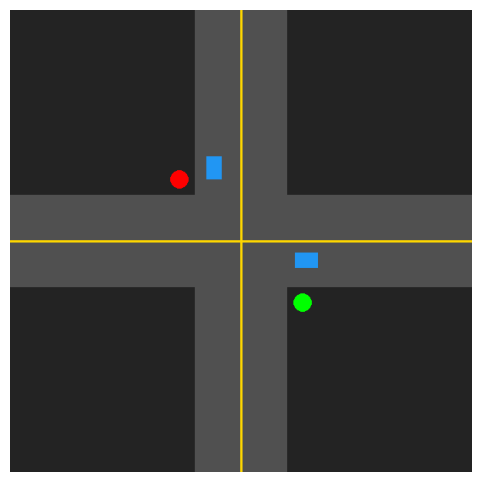

In [ ]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

import pygame
import random
import time
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay

SCREEN_WIDTH = 600
SCREEN_HEIGHT = 600
ROAD_WIDTH = 120

pygame.init()
screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))

# Colors
DARK_CITY = (35, 35, 35)
ROAD_GRAY = (80, 80, 80)
MARKER_YELLOW = (255, 215, 0)
RED_LIGHT = (255, 0, 0)
GREEN_LIGHT = (0, 255, 0)
COLOR_CAR = (33, 150, 243)

class Car:
    def __init__(self, direction):
        self.direction = direction
        self.color = COLOR_CAR
        self.length, self.width = 30, 20
        self.speed = 5
        self.is_stopped = False

        if direction == "NORTH":
            self.x = SCREEN_WIDTH // 2 - 35 - (self.width // 2)
            self.y = -self.length
        elif direction == "WEST":
            self.x = -self.length
            self.y = SCREEN_HEIGHT // 2 + 15 + (10 - self.width // 2)

    def move(self, signal_state):
        # Stop line boundaries before the intersection box
        if self.direction == "NORTH":
            if signal_state == "RED" and (self.y + self.length) >= 220 and self.y < 220:
                self.is_stopped = True
            else:
                self.is_stopped = False
                self.y += self.speed

        elif self.direction == "WEST":
            if signal_state == "GREEN" and (self.x + self.length) >= 220 and self.x < 220:
                # In this state, North-South is green, so East-West must stop!
                self.is_stopped = True
            else:
                self.is_stopped = False
                self.x += self.speed

    def draw(self, surface):
        if self.direction == "NORTH":
            pygame.draw.rect(surface, self.color, (self.x, self.y, self.width, self.length))
        else:
            pygame.draw.rect(surface, self.color, (self.x, self.y, self.length, self.width))

# Generate cars
random.seed(4)
traffic = [Car("NORTH"), Car("WEST")]
traffic[0].y -= 40 # Space out the north car slightly

# --- LIVE ANIMATION LOOP ---
# We will change the light from Green to Red halfway through to show them stopping!
current_signal = "GREEN"

for frame in range(80):
    if frame > 40:
        current_signal = "RED" # Trigger light change!

    # 1. Draw Map Base
    screen.fill(DARK_CITY)
    pygame.draw.rect(screen, ROAD_GRAY, ((SCREEN_WIDTH // 2) - (ROAD_WIDTH // 2), 0, ROAD_WIDTH, SCREEN_HEIGHT))
    pygame.draw.rect(screen, ROAD_GRAY, (0, (SCREEN_HEIGHT // 2) - (ROAD_WIDTH // 2), SCREEN_WIDTH, ROAD_WIDTH))
    pygame.draw.line(screen, MARKER_YELLOW, (SCREEN_WIDTH // 2, 0), (SCREEN_WIDTH // 2, SCREEN_HEIGHT), 3)
    pygame.draw.line(screen, MARKER_YELLOW, (0, SCREEN_HEIGHT // 2), (SCREEN_WIDTH, SCREEN_HEIGHT // 2), 3)

    # 2. Draw Traffic Lights (Circles on the corners)
    # North-South Light Indicator
    ns_color = GREEN_LIGHT if current_signal == "GREEN" else RED_LIGHT
    pygame.draw.circle(screen, ns_color, (SCREEN_WIDTH // 2 - 80, SCREEN_HEIGHT // 2 - 80), 12)

    # East-West Light Indicator
    ew_color = RED_LIGHT if current_signal == "GREEN" else GREEN_LIGHT
    pygame.draw.circle(screen, ew_color, (SCREEN_WIDTH // 2 + 80, SCREEN_HEIGHT // 2 + 80), 12)

    # 3. Physics Updates
    for car in traffic:
        car.move(current_signal)
        car.draw(screen)

    # 4. Refresh Display Frame Live in Colab Output
    pixel_matrix = pygame.surfarray.array3d(screen).transpose([1, 0, 2])

    ipythondisplay.clear_output(wait=True) # Clears previous snapshot
    plt.figure(figsize=(6, 6))
    plt.imshow(pixel_matrix)
    plt.axis("off")
    plt.show()

    time.sleep(0.03) # Match animation speed to ~30 FPS

Initial test for AIATSS

AI Override: North Queue (2) > West Queue (1). Switching Lights!
Stats -> Waiting Cars || North: 0 | West: 0


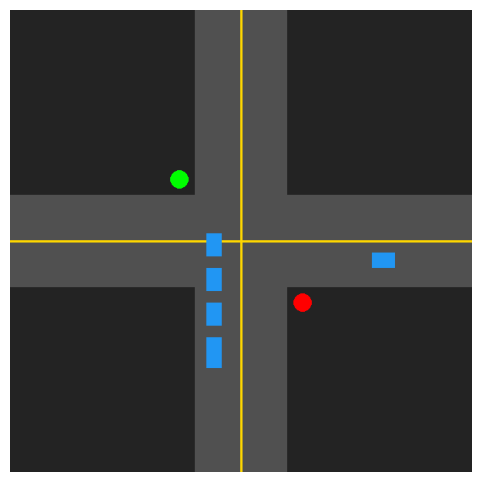

In [ ]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

import pygame
import random
import time
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay

SCREEN_WIDTH = 600
SCREEN_HEIGHT = 600
ROAD_WIDTH = 120

pygame.init()
screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))

# Colors
DARK_CITY = (35, 35, 35)
ROAD_GRAY = (80, 80, 80)
MARKER_YELLOW = (255, 215, 0)
RED_LIGHT = (255, 0, 0)
GREEN_LIGHT = (0, 255, 0)
COLOR_CAR = (33, 150, 243)

class SmartCar:
    def __init__(self, direction, initial_offset):
        self.direction = direction
        self.color = COLOR_CAR
        self.length, self.width = 30, 20
        self.speed = 5
        self.passed_intersection = False

        if direction == "NORTH":
            self.x = SCREEN_WIDTH // 2 - 35 - (self.width // 2)
            self.y = -self.length - initial_offset
        elif direction == "WEST":
            self.x = -self.length - initial_offset
            self.y = SCREEN_HEIGHT // 2 + 15 + (10 - self.width // 2)

    def move(self, current_signal):
        if self.direction == "NORTH":
            # If light is RED for North-South, stop before the line (y=220)
            if current_signal == "WEST_GREEN" and (self.y + self.length) >= 220 and self.y < 220:
                pass
            else:
                self.y += self.speed
                if self.y > 240:
                    self.passed_intersection = True

        elif self.direction == "WEST":
            # If light is GREEN for North-South (meaning Red for East-West), stop before line (x=220)
            if current_signal == "NS_GREEN" and (self.x + self.length) >= 220 and self.x < 220:
                pass
            else:
                self.x += self.speed
                if self.x > 240:
                    self.passed_intersection = True

    def draw(self, surface):
        if self.direction == "NORTH":
            pygame.draw.rect(surface, self.color, (self.x, self.y, self.width, self.length))
        else:
            pygame.draw.rect(surface, self.color, (self.x, self.y, self.length, self.width))

# --- CREATE HEAVY CONGESTION ON THE NORTH SIDE ---
# 5 cars queued up from the North, only 1 car from the West (Typical Hyderabad scenario!)
traffic_pool = [
    SmartCar("NORTH", 0),
    SmartCar("NORTH", 45),
    SmartCar("NORTH", 90),
    SmartCar("NORTH", 135),
    SmartCar("NORTH", 180),
    SmartCar("WEST", 0)
]

# The system starts by favoring the West side lane
current_signal = "WEST_GREEN"
ai_log = "AI Status: Initializing AIATSS Grid..."

for frame in range(100):
    # 1. AI SENSING & LOGIC STEP
    # Count how many vehicles are currently stuck waiting behind the stop line
    north_waiting = sum(1 for c in traffic_pool if c.direction == "NORTH" and not c.passed_intersection and (c.y + c.length) >= 210)
    west_waiting = sum(1 for c in traffic_pool if c.direction == "WEST" and not c.passed_intersection and (c.x + c.length) >= 210)

    # AI Decision Rule: Switch to whichever lane has more stranded vehicles!
    if north_waiting > west_waiting and current_signal == "WEST_GREEN":
        current_signal = "NS_GREEN"
        ai_log = f"AI Override: North Queue ({north_waiting}) > West Queue ({west_waiting}). Switching Lights!"
    elif west_waiting > north_waiting and current_signal == "NS_GREEN":
        current_signal = "WEST_GREEN"
        ai_log = f"AI Override: West Queue ({west_waiting}) > North Queue ({north_waiting}). Switching Lights!"

    # 2. Render Environment Assets
    screen.fill(DARK_CITY)
    pygame.draw.rect(screen, ROAD_GRAY, ((SCREEN_WIDTH // 2) - (ROAD_WIDTH // 2), 0, ROAD_WIDTH, SCREEN_HEIGHT))
    pygame.draw.rect(screen, ROAD_GRAY, (0, (SCREEN_HEIGHT // 2) - (ROAD_WIDTH // 2), SCREEN_WIDTH, ROAD_WIDTH))
    pygame.draw.line(screen, MARKER_YELLOW, (SCREEN_WIDTH // 2, 0), (SCREEN_WIDTH // 2, SCREEN_HEIGHT), 3)
    pygame.draw.line(screen, MARKER_YELLOW, (0, SCREEN_HEIGHT // 2), (SCREEN_WIDTH, SCREEN_HEIGHT // 2), 3)

    # 3. Paint Traffic Lights based on AI state
    ns_color = GREEN_LIGHT if current_signal == "NS_GREEN" else RED_LIGHT
    pygame.draw.circle(screen, ns_color, (SCREEN_WIDTH // 2 - 80, SCREEN_HEIGHT // 2 - 80), 12)

    ew_color = RED_LIGHT if current_signal == "NS_GREEN" else GREEN_LIGHT
    pygame.draw.circle(screen, ew_color, (SCREEN_WIDTH // 2 + 80, SCREEN_HEIGHT // 2 + 80), 12)

    # 4. Update and Render Vehicles
    for car in traffic_pool:
        car.move(current_signal)
        car.draw(screen)

    # 5. Flash Output to Screen Grid
    pixel_matrix = pygame.surfarray.array3d(screen).transpose([1, 0, 2])

    ipythondisplay.clear_output(wait=True)
    print("==========================================================================")
    print(ai_log)
    print(f"Stats -> Waiting Cars || North: {north_waiting} | West: {west_waiting}")
    print("==========================================================================")

    plt.figure(figsize=(6, 6))
    plt.imshow(pixel_matrix)
    plt.axis("off")
    plt.show()

    time.sleep(0.04)

Adding more lanes

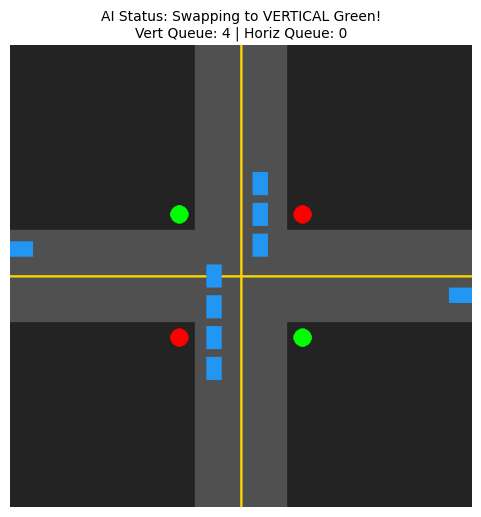

In [ ]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

import pygame
import time
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay

SCREEN_WIDTH = 600
SCREEN_HEIGHT = 600
ROAD_WIDTH = 120

pygame.init()
screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))

# Colors
DARK_CITY = (35, 35, 35)
ROAD_GRAY = (80, 80, 80)
MARKER_YELLOW = (255, 215, 0)
RED_LIGHT = (255, 0, 0)
GREEN_LIGHT = (0, 255, 0)
COLOR_CAR = (33, 150, 243)

class CrashProofSmartCar:
    def __init__(self, direction, initial_offset):
        self.direction = direction
        self.color = COLOR_CAR
        self.length, self.width = 30, 20
        self.speed = 5
        self.passed_intersection = False

        if direction == "NORTH":
            self.x = SCREEN_WIDTH // 2 - 35 - (self.width // 2)
            self.y = -self.length - initial_offset
        elif direction == "SOUTH":
            self.x = SCREEN_WIDTH // 2 + 15 + (10 - self.width // 2)
            self.y = SCREEN_HEIGHT + initial_offset
        elif direction == "WEST":
            self.x = -self.length - initial_offset
            self.y = SCREEN_HEIGHT // 2 + 15 + (10 - self.width // 2)
        elif direction == "EAST":
            self.x = SCREEN_WIDTH + initial_offset
            self.y = SCREEN_HEIGHT // 2 - 35 - (self.width // 2)

    def move(self, current_signal, colleagues):
        # 1. CRASH PREVENTION LOGIC (Look Ahead)
        for other in colleagues:
            if other == self or other.passed_intersection:
                continue

            # If a car is ahead in the same lane, check the distance
            if self.direction == "NORTH" and other.direction == "NORTH" and other.y > self.y:
                if other.y - (self.y + self.length) < 15: # Too close!
                    return # Stop moving to prevent a crash
            elif self.direction == "SOUTH" and other.direction == "SOUTH" and other.y < self.y:
                if self.y - (other.y + other.length) < 15:
                    return
            elif self.direction == "WEST" and other.direction == "WEST" and other.x > self.x:
                if other.x - (self.x + self.length) < 15:
                    return
            elif self.direction == "EAST" and other.direction == "EAST" and other.x < self.x:
                if self.x - (other.x + other.length) < 15:
                    return

        # 2. TRAFFIC SIGNAL LOGIC
        if self.direction == "NORTH":
            if current_signal == "HORIZ_GREEN" and (self.y + self.length) >= 220 and self.y < 220:
                pass
            else:
                self.y += self.speed
                if self.y > 380: self.passed_intersection = True

        elif self.direction == "SOUTH":
            if current_signal == "HORIZ_GREEN" and self.y <= 380 and (self.y + self.length) > 380:
                pass
            else:
                self.y -= self.speed
                if self.y < 220: self.passed_intersection = True

        elif self.direction == "WEST":
            if current_signal == "VERT_GREEN" and (self.x + self.length) >= 220 and self.x < 220:
                pass
            else:
                self.x += self.speed
                if self.x > 380: self.passed_intersection = True

        elif self.direction == "EAST":
            if current_signal == "VERT_GREEN" and self.x <= 380 and (self.x + self.length) > 380:
                pass
            else:
                self.x -= self.speed
                if self.x < 220: self.passed_intersection = True

    def draw(self, surface):
        if self.direction in ["NORTH", "SOUTH"]:
            pygame.draw.rect(surface, self.color, (self.x, self.y, self.width, self.length))
        else:
            pygame.draw.rect(surface, self.color, (self.x, self.y, self.length, self.width))

# Setup traffic pool (deliberately bunched together to test crash prevention)
full_grid_traffic = [
    CrashProofSmartCar("NORTH", 0), CrashProofSmartCar("NORTH", 40), CrashProofSmartCar("NORTH", 80), CrashProofSmartCar("NORTH", 120),
    CrashProofSmartCar("SOUTH", 0), CrashProofSmartCar("SOUTH", 40), CrashProofSmartCar("SOUTH", 80),
    CrashProofSmartCar("WEST", 0),
    CrashProofSmartCar("EAST", 0)
]

current_signal = "HORIZ_GREEN"
ai_log = "AI Status: Initializing Anti-Flicker Smooth Matrix..."

# Setup an inline display plot handle to prevent flashing
fig, ax = plt.subplots(figsize=(6, 6))
display_handle = ipythondisplay.display(fig, display_id=True)

for frame in range(120):
    # AI Sensing queues
    n_wait = sum(1 for c in full_grid_traffic if c.direction == "NORTH" and not c.passed_intersection and (c.y + c.length) >= 210)
    s_wait = sum(1 for c in full_grid_traffic if c.direction == "SOUTH" and not c.passed_intersection and c.y <= 390)
    w_wait = sum(1 for c in full_grid_traffic if c.direction == "WEST" and not c.passed_intersection and (c.x + c.length) >= 210)
    e_wait = sum(1 for c in full_grid_traffic if c.direction == "EAST" and not c.passed_intersection and c.x <= 390)

    total_vertical = n_wait + s_wait
    total_horizontal = w_wait + e_wait

    if total_vertical > total_horizontal and current_signal == "HORIZ_GREEN":
        current_signal = "VERT_GREEN"
        ai_log = "AI Status: Swapping to VERTICAL Green!"
    elif total_horizontal > total_vertical and current_signal == "VERT_GREEN":
        current_signal = "HORIZ_GREEN"
        ai_log = "AI Status: Swapping to HORIZONTAL Green!"

    # Draw static map components
    screen.fill(DARK_CITY)
    pygame.draw.rect(screen, ROAD_GRAY, ((SCREEN_WIDTH // 2) - (ROAD_WIDTH // 2), 0, ROAD_WIDTH, SCREEN_HEIGHT))
    pygame.draw.rect(screen, ROAD_GRAY, (0, (SCREEN_HEIGHT // 2) - (ROAD_WIDTH // 2), SCREEN_WIDTH, ROAD_WIDTH))
    pygame.draw.line(screen, MARKER_YELLOW, (SCREEN_WIDTH // 2, 0), (SCREEN_WIDTH // 2, SCREEN_HEIGHT), 3)
    pygame.draw.line(screen, MARKER_YELLOW, (0, SCREEN_HEIGHT // 2), (SCREEN_WIDTH, SCREEN_HEIGHT // 2), 3)

    # Draw Signals
    v_color = GREEN_LIGHT if current_signal == "VERT_GREEN" else RED_LIGHT
    h_color = RED_LIGHT if current_signal == "VERT_GREEN" else GREEN_LIGHT
    pygame.draw.circle(screen, v_color, (SCREEN_WIDTH // 2 - 80, SCREEN_HEIGHT // 2 - 80), 12)
    pygame.draw.circle(screen, v_color, (SCREEN_WIDTH // 2 + 80, SCREEN_HEIGHT // 2 + 80), 12)
    pygame.draw.circle(screen, h_color, (SCREEN_WIDTH // 2 - 80, SCREEN_HEIGHT // 2 + 80), 12)
    pygame.draw.circle(screen, h_color, (SCREEN_WIDTH // 2 + 80, SCREEN_HEIGHT // 2 - 80), 12)

    # Move and Draw cars safely
    for car in full_grid_traffic:
        car.move(current_signal, full_grid_traffic)
        car.draw(screen)

    # Render smoothly using the handle instead of clearing the output completely
    pixel_matrix = pygame.surfarray.array3d(screen).transpose([1, 0, 2])

    ax.clear()
    ax.imshow(pixel_matrix)
    ax.axis("off")
    ax.set_title(f"{ai_log}\nVert Queue: {total_vertical} | Horiz Queue: {total_horizontal}", fontsize=10)

    # Force the display to update the existing frame image layout
    display_handle.update(fig)
    time.sleep(0.03)

plt.close(fig)

Adding proper logic:

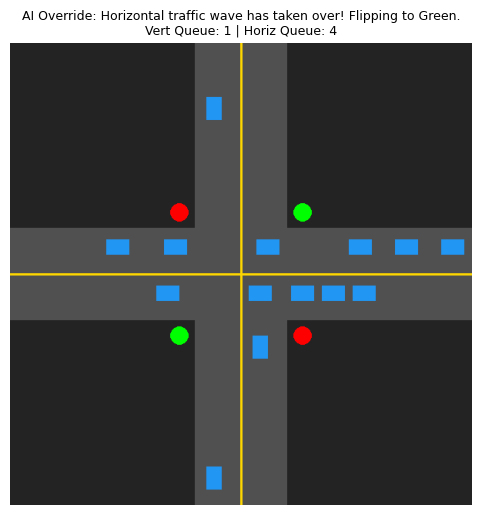

In [ ]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

import pygame
import random
import time
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay

SCREEN_WIDTH = 600
SCREEN_HEIGHT = 600
ROAD_WIDTH = 120

pygame.init()
screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))

# Colors
DARK_CITY = (35, 35, 35)
ROAD_GRAY = (80, 80, 80)
MARKER_YELLOW = (255, 215, 0)
RED_LIGHT = (255, 0, 0)
GREEN_LIGHT = (0, 255, 0)
COLOR_CAR = (33, 150, 243)

class ContinuousSmartCar:
    def __init__(self, direction):
        self.direction = direction
        self.color = COLOR_CAR
        self.length, self.width = 30, 20
        self.speed = 5
        self.passed_intersection = False

        # Spawn right at the edges of the screen layout
        if direction == "NORTH":
            self.x = SCREEN_WIDTH // 2 - 35 - (self.width // 2)
            self.y = -self.length
        elif direction == "SOUTH":
            self.x = SCREEN_WIDTH // 2 + 15 + (10 - self.width // 2)
            self.y = SCREEN_HEIGHT
        elif direction == "WEST":
            self.x = -self.length
            self.y = SCREEN_HEIGHT // 2 + 15 + (10 - self.width // 2)
        elif direction == "EAST":
            self.x = SCREEN_WIDTH
            self.y = SCREEN_HEIGHT // 2 - 35 - (self.width // 2)

    def move(self, current_signal, colleagues):
        # 1. Look ahead to avoid bumping into cars in front
        for other in colleagues:
            if other == self or other.passed_intersection:
                continue
            if self.direction == "NORTH" and other.direction == "NORTH" and other.y > self.y:
                if other.y - (self.y + self.length) < 15: return
            elif self.direction == "SOUTH" and other.direction == "SOUTH" and other.y < self.y:
                if self.y - (other.y + other.length) < 15: return
            elif self.direction == "WEST" and other.direction == "WEST" and other.x > self.x:
                if other.x - (self.x + self.length) < 15: return
            elif self.direction == "EAST" and other.direction == "EAST" and other.x < self.x:
                if self.x - (other.x + other.length) < 15: return

        # 2. Respond to the AI Traffic Signal
        if self.direction == "NORTH":
            if current_signal == "HORIZ_GREEN" and (self.y + self.length) >= 220 and self.y < 220:
                pass
            else:
                self.y += self.speed
                if self.y > 380: self.passed_intersection = True

        elif self.direction == "SOUTH":
            if current_signal == "HORIZ_GREEN" and self.y <= 380 and (self.y + self.length) > 380:
                pass
            else:
                self.y -= self.speed
                if self.y < 220: self.passed_intersection = True

        elif self.direction == "WEST":
            if current_signal == "VERT_GREEN" and (self.x + self.length) >= 220 and self.x < 220:
                pass
            else:
                self.x += self.speed
                if self.x > 380: self.passed_intersection = True

        elif self.direction == "EAST":
            if current_signal == "VERT_GREEN" and self.x <= 380 and (self.x + self.length) > 380:
                pass
            else:
                self.x -= self.speed
                if self.x < 220: self.passed_intersection = True

    def draw(self, surface):
        if self.direction in ["NORTH", "SOUTH"]:
            pygame.draw.rect(surface, self.color, (self.x, self.y, self.width, self.length))
        else:
            pygame.draw.rect(surface, self.color, (self.x, self.y, self.length, self.width))

# Initialize empty pool
dynamic_traffic = []
current_signal = "VERT_GREEN"
ai_log = "AI Status: Observing dynamic traffic pattern changes..."

fig, ax = plt.subplots(figsize=(6, 6))
display_handle = ipythondisplay.display(fig, display_id=True)

# Run for 200 frames so you can see the wave shift back and forth
for frame in range(200):

    # --- DYNAMIC RANDOM SPAWNING LOGIC ---
    # In the first half (frames 0-90), heavily flood Vertical lanes (North/South)
    if frame < 90:
        if frame % 12 == 0:  # High frequency spawn
            dynamic_traffic.append(ContinuousSmartCar(random.choice(["NORTH", "SOUTH"])))
        if frame % 45 == 0:  # Low frequency spawn for horizontal
            dynamic_traffic.append(ContinuousSmartCar(random.choice(["WEST", "EAST"])))

    # In the second half (frames 90-200), stop spawning vertical cars completely,
    # and start flooding the Horizontal lanes (West/East) to shift the congestion!
    else:
        if frame % 12 == 0:  # High frequency spawn for horizontal
            dynamic_traffic.append(ContinuousSmartCar(random.choice(["WEST", "EAST"])))
        if frame % 60 == 0:  # Rare spawn for vertical
            dynamic_traffic.append(ContinuousSmartCar(random.choice(["NORTH", "SOUTH"])))

    # --- AI BRAIN SENSING QUEUES ---
    n_wait = sum(1 for c in dynamic_traffic if c.direction == "NORTH" and not c.passed_intersection and (c.y + c.length) >= 210)
    s_wait = sum(1 for c in dynamic_traffic if c.direction == "SOUTH" and not c.passed_intersection and c.y <= 390)
    w_wait = sum(1 for c in dynamic_traffic if c.direction == "WEST" and not c.passed_intersection and (c.x + c.length) >= 210)
    e_wait = sum(1 for c in dynamic_traffic if c.direction == "EAST" and not c.passed_intersection and c.x <= 390)

    total_vertical = n_wait + s_wait
    total_horizontal = w_wait + e_wait

    # --- AI DECISION CORE ---
    if total_vertical > total_horizontal and current_signal == "HORIZ_GREEN":
        current_signal = "VERT_GREEN"
        ai_log = "AI Override: Vertical traffic wave is heavier! Flipping to Green."
    elif total_horizontal > total_vertical and current_signal == "VERT_GREEN":
        current_signal = "HORIZ_GREEN"
        ai_log = "AI Override: Horizontal traffic wave has taken over! Flipping to Green."

    # Render Graphics Environment
    screen.fill(DARK_CITY)
    pygame.draw.rect(screen, ROAD_GRAY, ((SCREEN_WIDTH // 2) - (ROAD_WIDTH // 2), 0, ROAD_WIDTH, SCREEN_HEIGHT))
    pygame.draw.rect(screen, ROAD_GRAY, (0, (SCREEN_HEIGHT // 2) - (ROAD_WIDTH // 2), SCREEN_WIDTH, ROAD_WIDTH))
    pygame.draw.line(screen, MARKER_YELLOW, (SCREEN_WIDTH // 2, 0), (SCREEN_WIDTH // 2, SCREEN_HEIGHT), 3)
    pygame.draw.line(screen, MARKER_YELLOW, (0, SCREEN_HEIGHT // 2), (SCREEN_WIDTH, SCREEN_HEIGHT // 2), 3)

    # Update Signals
    v_color = GREEN_LIGHT if current_signal == "VERT_GREEN" else RED_LIGHT
    h_color = RED_LIGHT if current_signal == "VERT_GREEN" else GREEN_LIGHT
    pygame.draw.circle(screen, v_color, (SCREEN_WIDTH // 2 - 80, SCREEN_HEIGHT // 2 - 80), 12)
    pygame.draw.circle(screen, v_color, (SCREEN_WIDTH // 2 + 80, SCREEN_HEIGHT // 2 + 80), 12)
    pygame.draw.circle(screen, h_color, (SCREEN_WIDTH // 2 - 80, SCREEN_HEIGHT // 2 + 80), 12)
    pygame.draw.circle(screen, h_color, (SCREEN_WIDTH // 2 + 80, SCREEN_HEIGHT // 2 - 80), 12)

    # Process and clean up out-of-bounds traffic array objects to prevent memory slowdowns
    for car in dynamic_traffic:
        car.move(current_signal, dynamic_traffic)
        car.draw(screen)

    # Clean up cars that left the map completely
    dynamic_traffic = [c for c in dynamic_traffic if not (c.y > SCREEN_HEIGHT + 50 or c.y < -50 or c.x > SCREEN_WIDTH + 50 or c.x < -50)]

    # Draw Output
    pixel_matrix = pygame.surfarray.array3d(screen).transpose([1, 0, 2])

    ax.clear()
    ax.imshow(pixel_matrix)
    ax.axis("off")
    ax.set_title(f"{ai_log}\nVert Queue: {total_vertical} | Horiz Queue: {total_horizontal}", fontsize=9)

    display_handle.update(fig)
    time.sleep(0.04)

plt.close(fig)

#As you can see in here initially, in the Vertical road there ar more number of Vehicles so it is green but, as the the vehicles pass the congession in the vertical lane decreases  b
#but it increases in the horizontal lane so, it will show green signal in the horizontal lane and red in the vertical lane.

# Adding Different types of vehicles

Orange- Motorbikes;
 Blue- Cars;
  Purple- Buses


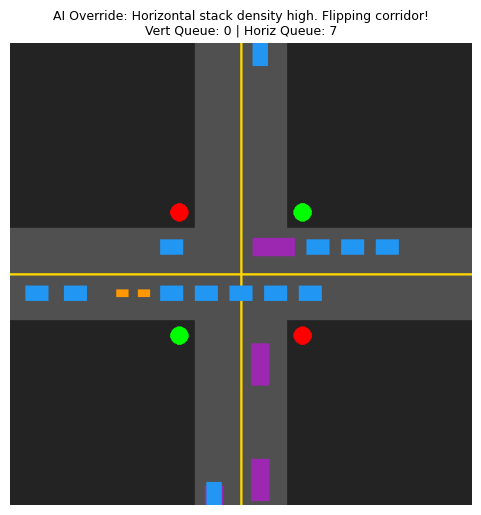

In [ ]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

import pygame
import random
import time
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay

SCREEN_WIDTH = 600
SCREEN_HEIGHT = 600
ROAD_WIDTH = 120

pygame.init()
screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))

# Colors
DARK_CITY = (35, 35, 35)
ROAD_GRAY = (80, 80, 80)
MARKER_YELLOW = (255, 215, 0)
RED_LIGHT = (255, 0, 0)
GREEN_LIGHT = (0, 255, 0)

# Vehicle Class Colors
COLOR_BIKE = (255, 152, 0)   # Orange for bikes/autos
COLOR_CAR = (33, 150, 243)   # Blue for standard cars
COLOR_BUS = (156, 39, 176)   # Purple for heavy buses/trucks

class AIATSSVehicle:
    def __init__(self, direction):
        self.direction = direction
        self.passed_intersection = False

        # Heterogeneous Traffic Profile Generation
        # 25% Bikes, 60% Cars, 15% Buses
        rand_type = random.random()
        if rand_type < 0.25:
            self.v_type = "BIKE"
            self.color = COLOR_BIKE
            self.length, self.width = 16, 10
            self.speed = 7  # Faster pacing
        elif rand_type < 0.85:
            self.v_type = "CAR"
            self.color = COLOR_CAR
            self.length, self.width = 30, 20
            self.speed = 5  # Standard pacing
        else:
            self.v_type = "BUS"
            self.color = COLOR_BUS
            self.length, self.width = 55, 24
            self.speed = 3  # Heavy vehicle slowing factor

        # Assign lane position coordinates based on directional vectors
        if direction == "NORTH":
            self.x = SCREEN_WIDTH // 2 - 35 - (self.width // 2)
            self.y = -self.length
        elif direction == "SOUTH":
            self.x = SCREEN_WIDTH // 2 + 15 + (10 - self.width // 2)
            self.y = SCREEN_HEIGHT
        elif direction == "WEST":
            self.x = -self.length
            self.y = SCREEN_HEIGHT // 2 + 15 + (10 - self.width // 2)
        elif direction == "EAST":
            self.x = SCREEN_WIDTH
            self.y = SCREEN_HEIGHT // 2 - 35 - (self.width // 2)

    def move(self, current_signal, colleagues):
        # 1. Dynamic Safe Spacing Check (Handles mixed sizing dimensions)
        for other in colleagues:
            if other == self or other.passed_intersection:
                continue

            # Distance buffer calculations keeping vehicle length in mind
            if self.direction == "NORTH" and other.direction == "NORTH" and other.y > self.y:
                if other.y - (self.y + self.length) < 18: return
            elif self.direction == "SOUTH" and other.direction == "SOUTH" and other.y < self.y:
                if self.y - (other.y + other.length) < 18: return
            elif self.direction == "WEST" and other.direction == "WEST" and other.x > self.x:
                if other.x - (self.x + self.length) < 18: return
            elif self.direction == "EAST" and other.direction == "EAST" and other.x < self.x:
                if self.x - (other.x + other.length) < 18: return

        # 2. Variable-Speed Movement & Signal Compliance
        if self.direction == "NORTH":
            if current_signal == "HORIZ_GREEN" and (self.y + self.length) >= 220 and self.y < 220:
                pass
            else:
                self.y += self.speed
                if self.y > 380: self.passed_intersection = True

        elif self.direction == "SOUTH":
            if current_signal == "HORIZ_GREEN" and self.y <= 380 and (self.y + self.length) > 380:
                pass
            else:
                self.y -= self.speed
                if self.y < 220: self.passed_intersection = True

        elif self.direction == "WEST":
            if current_signal == "VERT_GREEN" and (self.x + self.length) >= 220 and self.x < 220:
                pass
            else:
                self.x += self.speed
                if self.x > 380: self.passed_intersection = True

        elif self.direction == "EAST":
            if current_signal == "VERT_GREEN" and self.x <= 380 and (self.x + self.length) > 380:
                pass
            else:
                self.x -= self.speed
                if self.x < 220: self.passed_intersection = True

    def draw(self, surface):
        if self.direction in ["NORTH", "SOUTH"]:
            pygame.draw.rect(surface, self.color, (self.x, self.y, self.width, self.length))
        else:
            pygame.draw.rect(surface, self.color, (self.x, self.y, self.length, self.width))


# Main Multi-Class System Loop Initializations
multi_class_traffic = []
current_signal = "VERT_GREEN"
ai_log = "AIStatus: Balancing multi-class vehicle density tracks..."

fig, ax = plt.subplots(figsize=(6, 6))
display_handle = ipythondisplay.display(fig, display_id=True)

# Run for 220 steps to watch the changing mixtures pass through
for frame in range(220):

    # Wave Generator Logic
    if frame < 100:
        if frame % 10 == 0: # High spawn vertical
            multi_class_traffic.append(AIATSSVehicle(random.choice(["NORTH", "SOUTH"])))
        if frame % 40 == 0: # Low spawn horizontal
            multi_class_traffic.append(AIATSSVehicle(random.choice(["WEST", "EAST"])))
    else:
        if frame % 10 == 0: # High spawn horizontal
            multi_class_traffic.append(AIATSSVehicle(random.choice(["WEST", "EAST"])))
        if frame % 50 == 0: # Low spawn vertical
            multi_class_traffic.append(AIATSSVehicle(random.choice(["NORTH", "SOUTH"])))

    # Queue counters
    n_wait = sum(1 for c in multi_class_traffic if c.direction == "NORTH" and not c.passed_intersection and (c.y + c.length) >= 210)
    s_wait = sum(1 for c in multi_class_traffic if c.direction == "SOUTH" and not c.passed_intersection and c.y <= 390)
    w_wait = sum(1 for c in multi_class_traffic if c.direction == "WEST" and not c.passed_intersection and (c.x + c.length) >= 210)
    e_wait = sum(1 for c in multi_class_traffic if c.direction == "EAST" and not c.passed_intersection and c.x <= 390)

    total_vertical = n_wait + s_wait
    total_horizontal = w_wait + e_wait

    # Adaptive AI Signal Core
    if total_vertical > total_horizontal and current_signal == "HORIZ_GREEN":
        current_signal = "VERT_GREEN"
        ai_log = "AI Override: Vertical stack density high. Flipping corridor!"
    elif total_horizontal > total_vertical and current_signal == "VERT_GREEN":
        current_signal = "HORIZ_GREEN"
        ai_log = "AI Override: Horizontal stack density high. Flipping corridor!"

    # Graphics Rendering
    screen.fill(DARK_CITY)
    pygame.draw.rect(screen, ROAD_GRAY, ((SCREEN_WIDTH // 2) - (ROAD_WIDTH // 2), 0, ROAD_WIDTH, SCREEN_HEIGHT))
    pygame.draw.rect(screen, ROAD_GRAY, (0, (SCREEN_HEIGHT // 2) - (ROAD_WIDTH // 2), SCREEN_WIDTH, ROAD_WIDTH))
    pygame.draw.line(screen, MARKER_YELLOW, (SCREEN_WIDTH // 2, 0), (SCREEN_WIDTH // 2, SCREEN_HEIGHT), 3)
    pygame.draw.line(screen, MARKER_YELLOW, (0, SCREEN_HEIGHT // 2), (SCREEN_WIDTH, SCREEN_HEIGHT // 2), 3)

    # Render Lights
    v_color = GREEN_LIGHT if current_signal == "VERT_GREEN" else RED_LIGHT
    h_color = RED_LIGHT if current_signal == "VERT_GREEN" else GREEN_LIGHT
    pygame.draw.circle(screen, v_color, (SCREEN_WIDTH // 2 - 80, SCREEN_HEIGHT // 2 - 80), 12)
    pygame.draw.circle(screen, v_color, (SCREEN_WIDTH // 2 + 80, SCREEN_HEIGHT // 2 + 80), 12)
    pygame.draw.circle(screen, h_color, (SCREEN_WIDTH // 2 - 80, SCREEN_HEIGHT // 2 + 80), 12)
    pygame.draw.circle(screen, h_color, (SCREEN_WIDTH // 2 + 80, SCREEN_HEIGHT // 2 - 80), 12)

    # Move and display the vehicle stream
    for vehicle in multi_class_traffic:
        vehicle.move(current_signal, multi_class_traffic)
        vehicle.draw(screen)

    # Boundary cleanups
    multi_class_traffic = [v for v in multi_class_traffic if not (v.y > SCREEN_HEIGHT + 60 or v.y < -60 or v.x > SCREEN_WIDTH + 60 or v.x < -60)]

    # Stream refresh output
    pixel_matrix = pygame.surfarray.array3d(screen).transpose([1, 0, 2])

    ax.clear()
    ax.imshow(pixel_matrix)
    ax.axis("off")
    ax.set_title(f"{ai_log}\nVert Queue: {total_vertical} | Horiz Queue: {total_horizontal}", fontsize=9)

    display_handle.update(fig)
    time.sleep(0.04)

plt.close(fig)

#sometimes vehicles may collide the please re-run the cell